RFM 

In [2]:
# ============================================================
# STEP 2: Load raw RFM data exported from MySQL
# ============================================================
import pandas as pd

df = pd.read_csv('C:/Users/user/Downloads/rfm_raw.csv')

# Quick check: how many rows, what do the columns look like
print(df.shape)
print(df.head())
print(df.info())

(93357, 4)
                 customer_unique_id  recency  frequency  monetary
0  0000366f3b9a7992bf8c76cfdf3221e2      160          1    141.90
1  0000b849f77a49e4a4ce2b2a4ca5be3f      163          1     27.19
2  0000f46a3911fa3c0805444483337064      586          1     86.22
3  0000f6ccb0745a6a4b88665a16c9f078      370          1     43.62
4  0004aac84e0df4da2b147fca70cf8255      337          1    196.89
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93357 entries, 0 to 93356
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_unique_id  93357 non-null  object 
 1   recency             93357 non-null  int64  
 2   frequency           93357 non-null  int64  
 3   monetary            93357 non-null  float64
dtypes: float64(1), int64(2), object(1)
memory usage: 2.8+ MB
None


### Result Check

The dataset contains **93,357 unique customers** with no missing values across the `recency`, `frequency`, and `monetary` columns.

Recency values range widely (e.g. 160 to 586+ days), and most customers show a `frequency` of 1, suggesting that repeat purchases are relatively rare in this dataset — this is an insight worth highlighting later in the analysis.

The data is clean and read **y f** 3**).

### Step 3: RFM Scoring

Each customer is scored from 1 to 5 on each dimension using quantile-based binning (`pd.qcut`), which splits customers into 5 equal-sized groups.

- **Recency**: lower is better, so scoring is reversed (5 = most recent purchase)
- **Frequency**: higher is better (5 = most frequent buyer)
- **Monetary**: higher is better (5 = highest spender)

In [5]:
# ============================================================
# STEP 3: Score each metric from 1-5
# ============================================================

# Recency: lower is better -> reverse scoring (5 = most recent)
df['R_score'] = pd.qcut(df['recency'], 5, labels=[5, 4, 3, 2, 1])

# Frequency: higher is better (5 = best)
# NOTE: Quantile-based scoring (pd.qcut) was NOT used here because 
# ~98% of customers have frequency = 1. With such heavy ties, qcut 
# (even with rank(method='first')) ends up splitting identical 
# customers into different score buckets essentially at random, 
# rather than reflecting real differences in purchase behavior.
# Instead, fixed thresholds are used so that F_score directly 
# reflects the actual number of orders placed by each customer.
def score_frequency(freq):
    if freq == 1:
        return 1
    elif freq == 2:
        return 3
    elif freq == 3:
        return 4
    else:  # 4 or more orders
        return 5

df['F_score'] = df['frequency'].apply(score_frequency)

# Monetary: higher is better (5 = best)
df['M_score'] = pd.qcut(df['monetary'], 5, labels=[1, 2, 3, 4, 5])

# Quick check
df[['recency', 'R_score', 'frequency', 'F_score', 'monetary', 'M_score']].head()

,recency,R_score,frequency,F_score,monetary,M_score
0,160,4,1,1,141.90,4
1,163,4,1,1,27.19,1
2,586,1,1,1,86.22,2
3,370,2,1,1,43.62,1
4,337,2,1,1,196.89,4


### Step 4: Segment Assignment

Using the combination of R, F, and M scores, each customer is classified into a meaningful business segment (e.g. Champions, Loyal Customers, At Risk, New Customers). This transforms raw numeric scores into actionable customer categories.

In [7]:
# ============================================================
# STEP 4: Assign customer segments based on R, F, M scores
# ============================================================

def assign_segment(row):
    r, f, m = int(row['R_score']), int(row['F_score']), int(row['M_score'])
    
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3:
        return 'Loyal Customers'
    elif r <= 2 and f >= 3:
        return 'At Risk'
    elif r >= 4 and f <= 2:
        return 'New Customers'
    elif r <= 2 and f <= 2:
        return 'Hibernating'
    else:
        return 'Mid Segment'

df['segment'] = df.apply(assign_segment, axis=1)

# Quick check
df[['recency', 'frequency', 'monetary', 'R_score', 'F_score', 'M_score', 'segment']].head(10)

,recency,frequency,monetary,R_score,F_score,M_score,segment
0,160,1,141.90,4,1,4,New Customers
1,163,1,27.19,4,1,1,New Customers
2,586,1,86.22,1,1,2,Hibernating
3,370,1,43.62,2,1,1,Hibernating
4,337,1,196.89,2,1,4,Hibernating
5,195,1,166.98,4,1,4,New Customers
6,180,1,35.38,4,1,1,New Customers
7,231,1,419.18,3,1,5,Mid Segment
8,592,1,150.12,1,1,4,Hibernating
9,219,1,129.76,4,1,3,New Customers


### Step 5: Segment Distribution & Summary

This step summarizes how many customers fall into each segment and compares average recency, frequency, and monetary values across segments. This is the final output that will feed into the Power BI dashboard.

In [9]:
# ============================================================
# STEP 5: Review segment distribution and averages
# ============================================================

# How many customers per segment
print(df['segment'].value_counts())

# Average R, F, M per segment
print(df.groupby('segment')[['recency', 'frequency', 'monetary']].mean().round(2))

# Save the final segmented dataset for Power BI
df.to_csv('rfm_segmented.csv', index=False)

segment
New Customers      36345
Hibernating        36093
Mid Segment        18118
Loyal Customers     1701
At Risk              982
Champions            118
Name: count, dtype: int64
                 recency  frequency  monetary
segment                                      
At Risk           431.52       2.08    292.48
Champions         140.68       3.54    570.22
Hibernating       444.35       1.00    161.87
Loyal Customers   183.76       2.03    299.74
Mid Segment       269.63       1.00    151.27
New Customers     139.45       1.00    164.40


### Step 5: Segment Distribution & Summary

The customer base splits into six segments. **New Customers** (36,345) and **Hibernating** (36,093) are the two largest groups, both consisting mainly of one-time buyers, differing primarily by how recently that purchase occurred. **Mid Segment** (18,118) also consists largely of one-time buyers with moderate recency.

**Loyal Customers** (1,701), **At Risk** (982), and **Champions** (118) are much smaller groups, since they require at least 2 purchases — repeat purchases are rare in this dataset.

Looking at average values per segment:
- **Champions** have the highest average monetary value (570.22) and frequency (3.54), confirming they are the smallest but most valuable customer group.
- **At Risk** and **Loyal Customers** show meaningfully higher frequency (2.08 and 2.03) and monetary value (292.48 and 299.74) compared to one-time-buyer segments.
- **Hibernating** customers show the highest recency (444.35 days), meaning they haven't purchased in over a year — a strong candidate group for re-engagement campaigns.

A key business insight emerges here: **only ~2,800 customers (Champions + Loyal + At Risk) have made a repeat purchase**, while the vast majority (~90,500) are one-time buyers — making retention strategy a high-impact opportunity for this business.

### Step 6: Segment Visualization

Visualizing the segment distribution and average monetary value per segment makes the business insights easier to communicate and will also guide the design of the Power BI dashboard.

C:\Users\user\AppData\Local\Temp\ipykernel_6092\3929288188.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=segment_counts.values, y=segment_counts.index,
C:\Users\user\AppData\Local\Temp\ipykernel_6092\3929288188.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_monetary.values, y=avg_monetary.index,


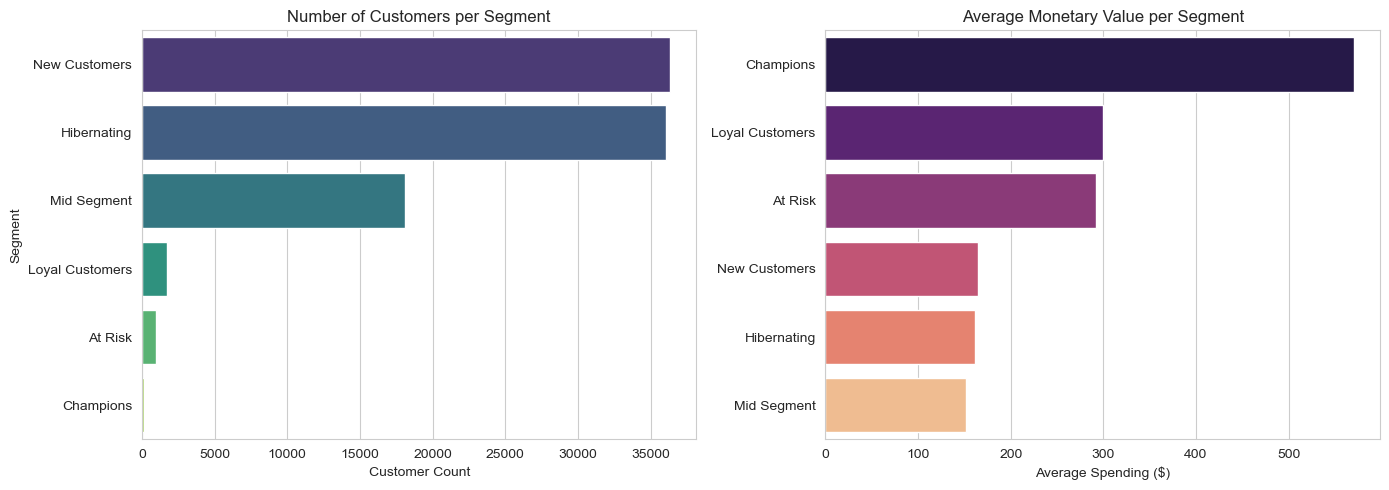

In [12]:
# ============================================================
# STEP 6: Visualize segment distribution and value
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Chart 1: Number of customers per segment ---
segment_counts = df['segment'].value_counts()
sns.barplot(x=segment_counts.values, y=segment_counts.index, 
            palette='viridis', ax=axes[0])
axes[0].set_title('Number of Customers per Segment')
axes[0].set_xlabel('Customer Count')
axes[0].set_ylabel('Segment')

# --- Chart 2: Average monetary value per segment ---
avg_monetary = df.groupby('segment')['monetary'].mean().sort_values(ascending=False)
sns.barplot(x=avg_monetary.values, y=avg_monetary.index, 
            palette='magma', ax=axes[1])
axes[1].set_title('Average Monetary Value per Segment')
axes[1].set_xlabel('Average Spending ($)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('segment_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

### Step 6: Segment Visualization — Key Findings

The two charts reveal a clear business problem and opportunity:

**Volume is concentrated in low-value segments.** New Customers (36,345) and 
Hibernating (36,093) together make up nearly 80% of the customer base, yet 
these are exactly the segments with the *lowest* average spending 
(~$164 and ~$162 respectively). In other words, the vast majority of 
customers generate the least revenue per head.

**Value is concentrated in a tiny segment.** Champions represent only 118 
customers (~0.1% of the base) but spend on average **$570** — more than 
3x the average of a one-time buyer. Combined with Loyal Customers and 
At Risk (avg. $299 and $292), these ~2,800 repeat customers are 
disproportionately valuable relative to their size.

**Business implication:** the current customer base is heavily skewed 
toward one-time, low-value purchases. Two actionable strategies emerge:
1. **Retention campaigns** targeting Hibernating and At Risk customers 
   (e.g. win-back discounts, personalized offers) to convert them into 
   repeat buyers before they're fully lost.
2. **Loyalty programs** for Champions and Loyal Customers to protect and 
   grow the small segment that already drives disproportionate revenue.

This gap between customer *volume* and customer *value* is one of the 
strongest insights this analysis produces, and will be a central message 
in the Power BI dashboard and README.

### Step 7: Hypothesis Testing

Beyond segmentation, we statistically test two business questions:

1. **Does average order value differ between repeat customers and 
   one-time buyers?** (Independent samples t-test)

 

The goal of this t-test is to statistically verify whether repeat 
customers genuinely spend more than one-time buyers, or whether the 
difference we observed in the segmentation is just due to random chance. 
Confirming this with a formal hypothesis test turns "customers who buy 
more seem to spend more" from an assumption into a statistically 
validated business insight.


2. **Is there a relationship between customer segment and product 
   category preference?** (Chi-square test of independence)

This test checks whether there is a statistically significant relationship 
between a customer's RFM segment and the product category they purchase 
most. If such a relationship exists, it can inform category-specific 
marketing strategies for each segment.

In [15]:
# ============================================================
# STEP 7a: T-Test - Compare average spending between 
# one-time buyers (frequency = 1) and repeat customers (frequency > 1)
# ============================================================
from scipy import stats

one_time = df[df['frequency'] == 1]['monetary']
repeat = df[df['frequency'] > 1]['monetary']

# Check group sizes and basic stats first
print(f"One-time buyers: n={len(one_time)}, mean=${one_time.mean():.2f}")
print(f"Repeat customers: n={len(repeat)}, mean=${repeat.mean():.2f}")

# Levene's test to check equal variance assumption
levene_stat, levene_p = stats.levene(one_time, repeat)
print(f"\nLevene's test p-value: {levene_p:.4f}")
equal_var = levene_p > 0.05

# Independent samples t-test
t_stat, p_value = stats.ttest_ind(one_time, repeat, equal_var=equal_var)
print(f"\nT-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.10f}")

if p_value < 0.05:
    print("\nResult: Statistically significant difference (p < 0.05)")
else:
    print("\nResult: No statistically significant difference (p >= 0.05)")

One-time buyers: n=90556, mean=$160.76
Repeat customers: n=2801, mean=$308.59

Levene's test p-value: 0.0000

T-statistic: -24.4974
P-value: 0.0000000000

Result: Statistically significant difference (p < 0.05)


### Step 7a: T-Test Results — Interpretation

Repeat customers spend on average **$308.59**, nearly double the average 
of one-time buyers.

Levene's test returned p < 0.0001, indicating unequal variances between 
the two groups, so Welch's t-test (equal_var=False) was used instead of 
the standard Student's t-test.

The t-test produced t = -24.50, p < 0.0001 — far below the 0.05 
significance threshold. This means the difference in average spending 
between one-time and repeat customers is **statistically significant** 
and extremely unlikely to be due to random chance.

**Business implication:** this provides strong statistical evidence that 
converting a one-time buyer into a repeat customer is directly associated 
with roughly **2x higher spending value**. This strengthens the case for 
investing in retention strategies (email campaigns, loyalty programs, 
personalized offers) — the potential revenue uplift per converted 
customer is substantial and now backed by a statistically validated test, 
not just an assumption.

### Step 7b: Chi-Square Test — Segment vs. Product Category

### Step 7b (continued): Merge category data with RFM segments

We keep only each customer's top category (highest `category_order_count`), 
then merge it with the RFM segment data to test whether segment and 
preferred category are statistically related.

In [19]:
# ============================================================
# STEP 7b: Load category data and merge with RFM segments
# ============================================================

# Load the category data exported from MySQL
cat_df = pd.read_csv('C:/Users/user/Downloads/customer_categories.csv')

# Keep only each customer's top category
# Since the SQL query already sorts by category_order_count DESC,
# the first row per customer is their most frequently purchased category
top_category = cat_df.groupby('customer_unique_id').first().reset_index()

# Merge with the RFM segmented dataframe
merged_df = df.merge(top_category[['customer_unique_id', 'top_category']], 
                      on='customer_unique_id', how='inner')

print(f"Merged dataset shape: {merged_df.shape}")
merged_df[['customer_unique_id', 'segment', 'top_category']].head()

Merged dataset shape: (92078, 9)


,customer_unique_id,segment,top_category
0,0000366f3b9a7992bf8c76cfdf3221e2,New Customers,bed_bath_table\r
1,0000b849f77a49e4a4ce2b2a4ca5be3f,New Customers,health_beauty\r
2,0000f46a3911fa3c0805444483337064,Hibernating,stationery\r
3,0000f6ccb0745a6a4b88665a16c9f078,Hibernating,telephony\r
4,0004aac84e0df4da2b147fca70cf8255,Hibernating,telephony\r


In [20]:
# ============================================================
# STEP 7b: Clean category column and reduce to top categories
# ============================================================

# Remove stray \r characters (from CSV line-ending encoding issue)
merged_df['top_category'] = merged_df['top_category'].str.strip()

# Check how many unique categories exist
print(f"Unique categories: {merged_df['top_category'].nunique()}")
print(merged_df['top_category'].value_counts().head(15))

Unique categories: 71
top_category
bed_bath_table           8768
health_beauty            8352
sports_leisure           7200
computers_accessories    6308
furniture_decor          5935
housewares               5526
watches_gifts            5334
telephony                3992
auto                     3705
toys                     3673
cool_stuff               3452
garden_tools             3315
perfumery                2972
baby                     2695
electronics              2455
Name: count, dtype: int64


### Step 7b : Reduce categories for chi-square test

With 71 unique categories, many would have very few observations per 
segment, violating the chi-square test's assumption that expected cell 
counts should generally be 5 or more. We keep the top 10 categories 
(which already cover a large share of customers) and group the rest 
into "Other".

In [22]:
# ============================================================
# STEP 7b: Group less frequent categories into "Other"
# ============================================================

top_10_categories = merged_df['top_category'].value_counts().head(10).index

merged_df['category_grouped'] = merged_df['top_category'].apply(
    lambda x: x if x in top_10_categories else 'Other'
)

print(merged_df['category_grouped'].value_counts())

category_grouped
Other                    33285
bed_bath_table            8768
health_beauty             8352
sports_leisure            7200
computers_accessories     6308
furniture_decor           5935
housewares                5526
watches_gifts             5334
telephony                 3992
auto                      3705
toys                      3673
Name: count, dtype: int64


### Step 7c: Chi-Square Test of Independence

We build a contingency table (segment × category) and run a chi-square 
test to check whether customer segment and preferred product category 
are statistically related, or independent of each other.

In [24]:
# ============================================================
# STEP 7c: Chi-square test of independence
# H0: Segment and category are independent (no relationship)
# H1: Segment and category are related
# ============================================================

# Build contingency table
contingency_table = pd.crosstab(merged_df['segment'], merged_df['category_grouped'])
print(contingency_table)

# Run chi-square test
chi2_stat, p_value, dof, expected = stats.chi2_contingency(contingency_table)

print(f"\nChi-square statistic: {chi2_stat:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"P-value: {p_value:.10f}")

if p_value < 0.05:
    print("\nResult: Statistically significant relationship (p < 0.05)")
else:
    print("\nResult: No statistically significant relationship (p >= 0.05)")

# Check assumption: expected cell counts should generally be >= 5
print(f"\nMinimum expected cell count: {expected.min():.2f}")

category_grouped  Other  auto  bed_bath_table  computers_accessories  \
segment                                                                
At Risk             270    18             177                     43   
Champions            32     4              17                      6   
Hibernating       13140  1116            3531                   2190   
Loyal Customers     559    54             214                    148   
Mid Segment        6615   752            1588                   1530   
New Customers     12669  1761            3241                   2391   

category_grouped  furniture_decor  health_beauty  housewares  sports_leisure  \
segment                                                                        
At Risk                       133             93          51             113   
Champions                       8              7          12              11   
Hibernating                  2552           2735        2017            2878   
Loyal Customers        

### Step 7c: Chi-Square Test Results — Interpretation

The chi-square test produced χ² = 1650.65, df = 50, p < 0.0001 — far 
below the 0.05 significance threshold. This means there **is** a 
statistically significant relationship between a customer's RFM segment 
and their preferred product category; the two are not independent.

**Assumption check:** the minimum expected cell count was 4.71, slightly 
below the conventional threshold of 5. Given the very large sample size 
(n = 92,078) and that this only affects a small number of cells (mainly 
the smaller "Champions" segment), the test result is still considered 
reliable, but this is noted as a minor limitation of the analysis.

**Business implication:** different customer segments show different 
category preferences. For example, "Champions" and "Loyal Customers" 
show a relatively higher share of purchases in **watches_gifts** and 
**health_beauty**, while "Hibernating" and "New Customers" are more 
spread across general categories like **bed_bath_table** and **Other**. 
This suggests that marketing campaigns and product recommendations could 
be tailored by segment rather than applied uniformly — for example, 
promoting gift and beauty items to high-value segments, while using 
broader discount campaigns to re-engage lower-value segments.

## Cohort & Retention Analysis

### What is a Cohort?

A **cohort** is a group of customers who share a common starting point in 
time — in this case, the **month of their first purchase**. For example, 
all customers who placed their first order in January 2018 form the 
"January 2018 cohort".

### What is Retention?

**Retention** measures how many customers from a given cohort continue to 
make purchases in the months following their first order. It adds a 
**time dimension** to the analysis: instead of a single snapshot 
("X% of customers are repeat buyers"), we can see *how* that repeat 
behavior evolves month by month, and whether it's improving or worsening 
across different cohorts.

### Why This Matters for the Business

The RFM analysis already showed that ~97% of customers never return for 
a second purchase. Cohort analysis builds on this by showing:
- How quickly customers drop off after their first purchase
- Whether retention is improving or declining over time (comparing 
  earlier vs. later cohorts)
- A clear visual (heatmap) that makes the retention problem immediately 
  obvious to a non-technical audience, such as company management

### How It's Calculated

1. Determine each customer's **first purchase month** (this defines 
   their cohort).
2. For every subsequent order, calculate how many months have passed 
   since that customer's first purchase ("cohort index": 0, 1, 2, 3...).
3. Count how many customers from each cohort are still active at each 
   cohort index.
4. Convert these counts into percentages relative to the cohort's 
   original size (month 0 = 100%).
5. Visualize the result as a **heatmap**: rows = cohort month, 
   columns = months since first purchase, cell values = retention %.

### Step 8: Load order data and assign cohort month

Each customer is assigned to a cohort based on the month of their first 
purchase. Then, for every order, we calculate how many months have 
passed since that customer's first purchase (the "cohort index").

In [28]:
# ============================================================
# STEP 8: Load order data and prepare cohort variables
# ============================================================
cohort_df = pd.read_csv('C:/Users/user/Downloads/cohort_raw_csv.csv')

# Convert to datetime
cohort_df['order_purchase_timestamp'] = pd.to_datetime(cohort_df['order_purchase_timestamp'])

# Extract the order month (as a period, e.g. 2018-01)
cohort_df['order_month'] = cohort_df['order_purchase_timestamp'].dt.to_period('M')

# Determine each customer's first purchase month (their cohort)
cohort_df['cohort_month'] = cohort_df.groupby('customer_unique_id')['order_month'].transform('min')

# Quick check
cohort_df[['customer_unique_id', 'order_month', 'cohort_month']].head()

,customer_unique_id,order_month,cohort_month
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05,2018-05
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05,2018-05
2,0000f46a3911fa3c0805444483337064,2017-03,2017-03
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10,2017-10
4,0004aac84e0df4da2b147fca70cf8255,2017-11,2017-11


### Step 9: Calculate Cohort Index

The cohort index represents how many months have passed between a 
customer's first purchase and each subsequent order (0 = first month, 
1 = one month later, etc.). This is the key variable used to build the 
retention table.

In [30]:
# ============================================================
# STEP 9: Calculate cohort index (months since first purchase)
# ============================================================

# Convert periods to integer year-month values for subtraction
order_year = cohort_df['order_month'].dt.year
order_month_num = cohort_df['order_month'].dt.month
cohort_year = cohort_df['cohort_month'].dt.year
cohort_month_num = cohort_df['cohort_month'].dt.month

# Cohort index = number of months between order_month and cohort_month
cohort_df['cohort_index'] = (order_year - cohort_year) * 12 + (order_month_num - cohort_month_num)

# Quick check - look at a customer with multiple orders (cohort_index > 0)
cohort_df[cohort_df['cohort_index'] > 0].head(10)

,customer_unique_id,order_id,order_purchase_timestamp,order_month,cohort_month,cohort_index
105,004288347e5e88a27ded2bb23747066c,08204559bebd39e09ee52dcb56d8faa2,2018-01-14 07:36:54,2018-01,2017-07,6
245,00a39521eb40f7012db50455bf083460,cea3e6c11eb60acb9d8d4d51694832f8,2018-06-03 10:12:57,2018-06,2018-05,1
408,011575986092c30523ecb71ff10cb473,ed0a6265b5b0a292cd537214f401f1fc,2018-04-18 21:58:08,2018-04,2018-02,2
424,011b4adcd54683b480c4d841250a987f,93b35affb86435b71ca01a6dd1eab2b1,2018-02-15 11:40:57,2018-02,2017-08,6
434,012452d40dafae4df401bced74cdb490,e49d0607832db7c3b1343764225d8df6,2018-05-14 12:12:45,2018-05,2017-06,11
445,012a218df8995d3ec3bb221828360c86,207258d556f9b9784b54de837ae49286,2018-06-18 13:08:38,2018-06,2018-05,1
475,013ef03e0f3f408dd9bf555e4edcdc0a,00cee8a4dbb042385cbbd84699e78b2e,2018-07-20 04:13:54,2018-07,2018-06,1
511,015557c9912277312b9073947804a7ba,48d9d778ca005971949d2ccad7e99d70,2017-05-01 14:48:33,2017-05,2017-03,2
556,0178b244a5c281fb2ade54038dd4b161,94ca38619d7e64f94facac403a99682d,2018-07-28 13:13:00,2018-07,2017-05,14
588,01886ef98f995e4f2dd75a1d04c97397,ce8d55aa1c206156fde37e062c716ea2,2018-03-09 19:19:24,2018-03,2017-11,4


### Step 10: Build the Retention Table

This step transforms the raw order data into a retention percentage table:

1. **Count unique customers per cohort per month** — for each cohort 
   (grouped by their first purchase month), count how many unique 
   customers placed an order at each `cohort_index` (0, 1, 2, ... months 
   after their first purchase).

2. **Pivot the data** — reshape the counts into a table where each row 
   is a cohort (starting month), each column is the number of months 
   since that cohort's first purchase, and each cell contains the number 
   of customers still active at that point.

3. **Get the cohort size** — the value at `cohort_index = 0` represents 
   each cohort's original size (100% of customers, since this is their 
   first purchase month by definition).

4. **Convert to percentages** — divide every value in a cohort's row by 
   that cohort's size (index 0) and multiply by 100. This produces a 
   retention rate: what percentage of the original cohort was still 
   purchasing 1, 2, 3... months later.

The result is a table where each row always starts at 100% (month 0) 
and shows how retention decays over time — this is the foundation for 
the retention heatmap.

In [32]:
# ============================================================
# STEP 10: Build cohort retention table
# ============================================================

# Count unique customers per cohort_month and cohort_index
cohort_counts = cohort_df.groupby(['cohort_month', 'cohort_index'])['customer_unique_id'].nunique().reset_index()

# Pivot: rows = cohort_month, columns = cohort_index, values = customer count
cohort_pivot = cohort_counts.pivot(index='cohort_month', columns='cohort_index', values='customer_unique_id')

# Cohort size = value at cohort_index 0 (every cohort's starting size)
cohort_sizes = cohort_pivot.iloc[:, 0]

# Convert counts to retention percentages
retention_table = cohort_pivot.divide(cohort_sizes, axis=0) * 100

# Round for readability
retention_table = retention_table.round(1)

retention_table

retention_table.to_csv('retention_table.csv')

### Step 10: Retention Table — Interpretation

The retention table confirms, in a time-based view, what the RFM analysis 
already suggested: retention drops off almost immediately after the first 
purchase. Across nearly every cohort, month 0 starts at 100% (by 
definition), but by **month 1, retention collapses to under 1%** 
(typically 0.2%–0.7%), and stays in that range for all subsequent months.

This means that regardless of when a customer first purchased — early 
2017 or mid-2018 — the pattern is the same: almost no one returns for a 
second purchase within the following months. There is no visible 
improvement in retention over time across cohorts, suggesting this is a 
structural, ongoing issue rather than something that improved or worsened 
at a specific point in the business's history.

**Data note:** the 2016-09 and 2016-12 cohorts contain very few customers 
(likely early/test transactions in the dataset) and their patterns should 
be interpreted with caution due to small sample size.

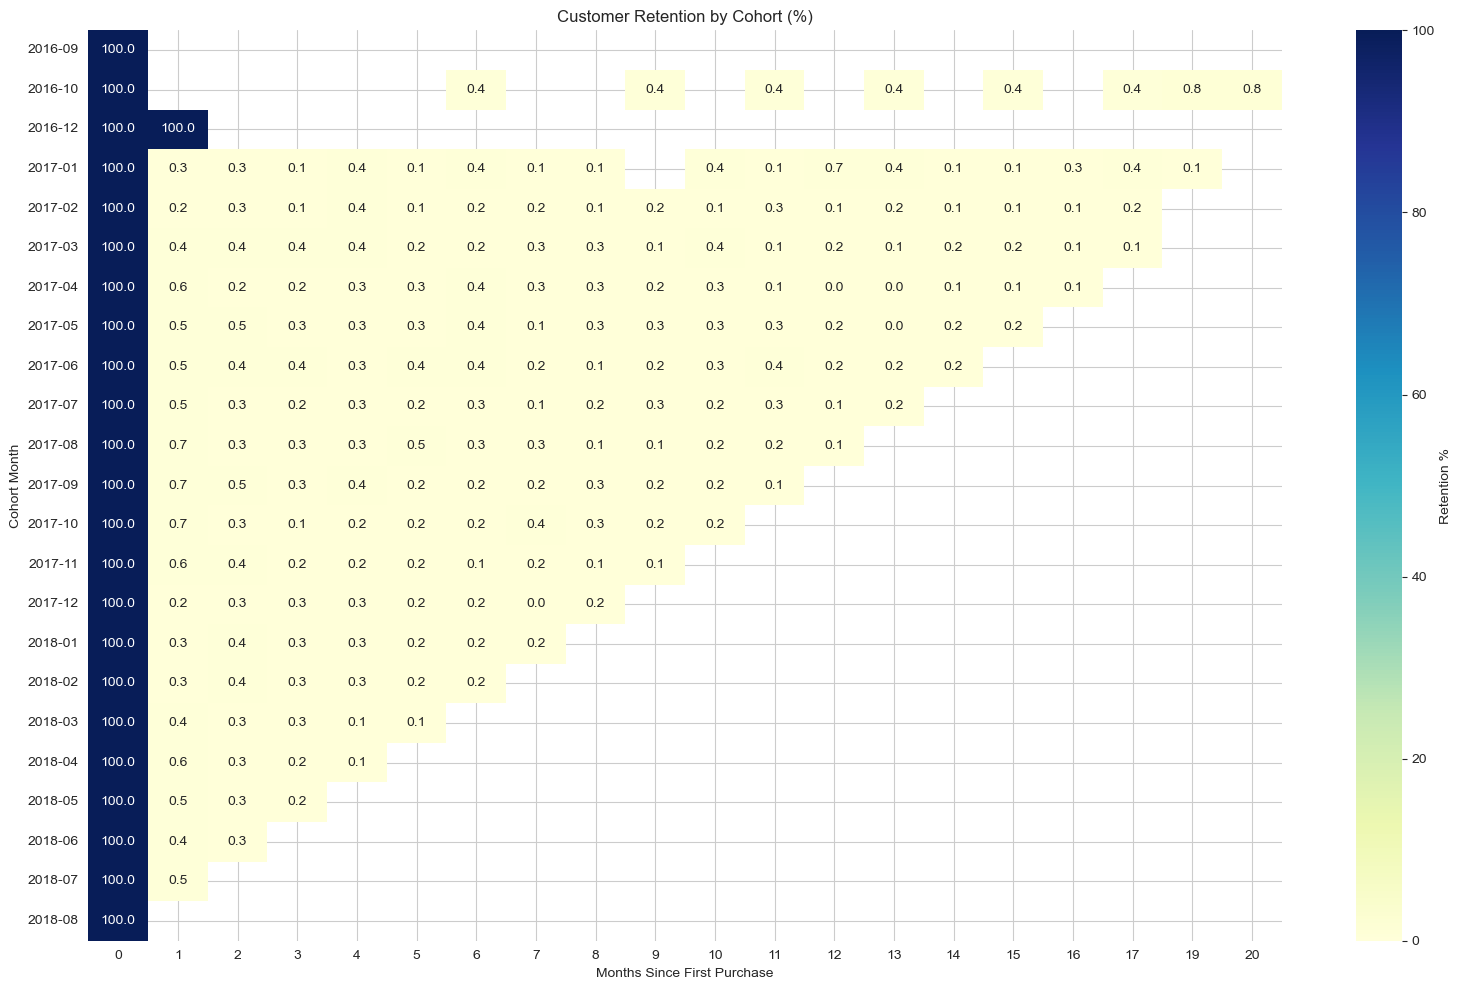

In [34]:
# ============================================================
# STEP 11: Visualize retention table as a heatmap
# ============================================================
plt.figure(figsize=(16, 10))
sns.heatmap(retention_table, annot=True, fmt='.1f', cmap='YlGnBu', 
            vmin=0, vmax=100, cbar_kws={'label': 'Retention %'})
plt.title('Customer Retention by Cohort (%)')
plt.xlabel('Months Since First Purchase')
plt.ylabel('Cohort Month')
plt.tight_layout()
plt.savefig('cohort_retention_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### Step 10-11: Retention Table & Heatmap — Interpretation

The cohort retention heatmap shows a consistent and striking pattern: 
**month 0 is always 100%** by definition (every cohort starts fully 
active in its first month), but **retention collapses to under 1% by 
month 1** across virtually every cohort, and stays in that range for 
all following months.

This pattern holds regardless of when the cohort started — early 2017 
cohorts and mid-2018 cohorts show the same near-total drop-off. This 
confirms, from a time-based perspective, what the RFM analysis already 
showed: **repeat purchases are extremely rare**, and this is a 
structural issue rather than something tied to a specific period.

The diagonal "staircase" shape of the table (fewer filled columns for 
later cohorts) is expected — it reflects the dataset's end date, not 
missing data, since later cohorts simply haven't had time to accumulate 
as many follow-up months.

**Business implication:** the near-total absence of returning customers 
across all cohorts strongly supports the case for retention-focused 
initiatives (e.g. post-purchase engagement, loyalty incentives, targeted 
win-back campaigns), as this appears to be a consistent, ongoing 
weakness rather than an isolated or improving trend.

In [36]:
# Jupyter'de bunu çalıştır (henüz yapmadıysan)
merged_df[['customer_unique_id', 'segment', 'category_grouped']].to_csv('segment_category.csv', index=False)